# Walmart Store Sales Forecasting — DLinear


In [1]:
%pip install -q seaborn mlflow dagshub wandb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 699.3 kB/s eta 0:00:00 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 53.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 94.3 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 72.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.0/121.0 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━

In [2]:
import os
if not os.path.exists("preprocessing.py"):
    !wget -q https://raw.githubusercontent.com/romaxod/ML-FINAL/main/preprocessing.py \
            https://raw.githubusercontent.com/romaxod/ML-FINAL/main/evaluation.py \
            https://raw.githubusercontent.com/romaxod/ML-FINAL/main/models.py

In [3]:
import os, gc, json, time, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import mlflow

import preprocessing as prep
import evaluation as ev
from preprocessing import BASE_COLS, MD_COLS, WalmartFeatureBuilder, \
    feature_columns, log1p_clip, expm1_inv, calendar_frame
from evaluation import wmae

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
sns.set_style("whitegrid")
SEED = 42
np.random.seed(SEED)
os.makedirs("pictures", exist_ok=True)

CODE_PATHS = ["preprocessing.py", "evaluation.py", "models.py"]

ARCH = "DLinear"


In [4]:
import dagshub

DAGSHUB_USER = "rkvit23"
DAGSHUB_REPO = "ML-FINAL"

dagshub.init(repo_owner=DAGSHUB_USER, repo_name=DAGSHUB_REPO, mlflow=True)
mlflow.set_tracking_uri(f"https://dagshub.com/{DAGSHUB_USER}/{DAGSHUB_REPO}.mlflow")

EXPERIMENT_NAME = f"{ARCH}_Training"
mlflow.set_experiment(EXPERIMENT_NAME)
print("MLflow experiment:", EXPERIMENT_NAME)

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=3e31282c-1d0a-45f3-84db-de83cd12200d&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=312b3b49c22e6e5675dcb29349d2f6a7fc0af1188d5c6143cb915abfe5a96ae2




Accessing as rkvit23

Initialized MLflow to track repo "rkvit23/ML-FINAL"

Repository rkvit23/ML-FINAL initialized!

MLflow experiment: DLinear_Training


In [5]:
import wandb

WANDB_PROJECT = "walmart-final"
WANDB_ENTITY  = "rkvit23-free-university-of-tbilisi-"

wandb.login()

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

  2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

  ········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: rkvit23 (rkvit23-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [6]:
if os.path.exists("/kaggle/input"):
    !ls /kaggle/input/competitions/
    prep.CANDIDATE_DIRS.append("/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/")

walmart-recruiting-store-sales-forecasting


In [7]:
train_raw, test_raw, features_raw, stores_raw = prep.load_data()

TRAIN_START, TRAIN_END = train_raw.Date.min(), train_raw.Date.max()
TEST_START,  TEST_END  = test_raw.Date.min(),  test_raw.Date.max()
HORIZON = test_raw.Date.nunique()

print("train:", train_raw.shape, TRAIN_START.date(), "->", TRAIN_END.date(),
      "| weeks:", train_raw.Date.nunique())
print("test :", test_raw.shape,  TEST_START.date(),  "->", TEST_END.date(),
      "| weeks:", HORIZON)
print("series (Store, Dept) in train:", train_raw.groupby(["Store", "Dept"]).ngroups)

train: (421570, 5) 2010-02-05 -> 2012-10-26 | weeks: 143
test : (115064, 4) 2012-11-02 -> 2013-07-26 | weeks: 39
series (Store, Dept) in train: 3331


In [8]:
features_clean = prep.clean_features(features_raw)

with mlflow.start_run(run_name=f"{ARCH}_Cleaning"):
    mlflow.log_params({
        "markdown_nan": "fill 0 + MarkDown_missing flag",
        "cpi_unemployment_nan": "per-store ffill/bfill",
        "negative_sales": "kept (returns are real signal)",
        "merge": "train/test LEFT JOIN stores, features",
    })
    mlflow.log_metrics({
        "n_rows_train": len(train_raw),
        "n_rows_test": len(test_raw),
        "n_series": train_raw.groupby(["Store", "Dept"]).ngroups,
        "n_negative_sales": int((train_raw.Weekly_Sales < 0).sum()),
        "pct_markdown_missing": float(features_raw[MD_COLS].isna().all(axis=1).mean()),
    })
print("cleaning done")

🏃 View run DLinear_Cleaning at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/5/runs/6845c2518b904650836521f4a0276607
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/5
cleaning done


## Windowing (global model)


In [9]:
dm = prep.build_series_matrix(train_raw, HORIZON)
Y, Ys, scale = dm.Y, dm.Ys, dm.scale
series_idx, all_dates, T = dm.series_idx, dm.all_dates, dm.T
w_week, S = dm.w_week, dm.n_series
VAL_CUT, val_dates = dm.val_cut, dm.val_dates
val_actual = train_raw[train_raw.Date >= val_dates[0]][
    ["Store", "Dept", "Date", "Weekly_Sales", "IsHoliday"]].copy()

with mlflow.start_run(run_name=f"{ARCH}_Windowing"):
    mlflow.log_params({
        "fill_missing_weeks": "0 (dept not trading)",
        "negatives": "clipped to 0",
        "scaling": "per-series mean, floor=1.0",
        "strategy": "global model, direct multi-horizon H=39",
        "val": "last 39 weeks of train",
    })
    mlflow.log_metrics({"n_series": S, "n_weeks": T, "obs_fraction": dm.obs_frac})
print(f"matrix {Y.shape} | observed fraction {dm.obs_frac:.3f} | VAL_CUT={VAL_CUT}")

🏃 View run DLinear_Windowing at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/5/runs/067f4e759f5f4f939e7d79f6caeb1505
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/5
matrix (3331, 143) | observed fraction 0.885 | VAL_CUT=104


In [10]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)

def make_windows(L, H, t_max):
    xs, ys, ws = [], [], []
    for t in range(L, t_max - H + 1):
        xs.append(Ys[:, t - L:t])
        ys.append(Ys[:, t:t + H])
        ws.append(np.tile(w_week[t:t + H], (S, 1)))
    X = np.concatenate(xs); Yt = np.concatenate(ys); W = np.concatenate(ws)
    SC = np.tile(scale[:, 0], t_max - H + 1 - L)
    keep = X.sum(axis=1) > 0
    return (torch.tensor(X[keep]), torch.tensor(Yt[keep]),
            torch.tensor(W[keep]), torch.tensor(SC[keep]))

def forecast_matrix(model, L, t_end):
    model.eval()
    with torch.no_grad():
        x = torch.tensor(Ys[:, t_end - L:t_end]).to(DEVICE)
        return model(x).cpu().numpy() * scale

def val_wmae_of(model, L):
    pred = forecast_matrix(model, L, VAL_CUT)
    dfp = pd.DataFrame(pred, index=series_idx, columns=val_dates)
    dfp.columns.name = "Date"
    long = dfp.stack().rename("pred").reset_index()
    m = val_actual.merge(long, on=["Store", "Dept", "Date"], how="left")
    m["pred"] = m["pred"].fillna(0).clip(lower=0)
    return wmae(m.Weekly_Sales, m.pred, m.IsHoliday), m

def train_model(model, cfg, run_name, log_wandb=True, init_wandb=True,
                t_max=None, epochs=None, eval_val=True):
    t_max = t_max or VAL_CUT
    X, Yt, W, SC = make_windows(cfg["L"], HORIZON, t_max)
    dl_ = DataLoader(TensorDataset(X, Yt, W, SC),
                     batch_size=cfg.get("batch", 1024), shuffle=True)
    opt = torch.optim.Adam(model.parameters(), lr=cfg.get("lr", 1e-3),
                           weight_decay=cfg.get("weight_decay", 0.0))
    n_epochs = epochs or cfg.get("epochs", 40)
    patience = cfg.get("patience", 6)
    best_v, best_ep, best_state, bad = float("inf"), 0, None, 0
    hist = []
    if log_wandb and init_wandb:
        wandb.init(project=WANDB_PROJECT, entity=WANDB_ENTITY, name=run_name,
                   group=f"{ARCH}_Training", config=cfg, reinit=True)
    with mlflow.start_run(run_name=run_name):
        mlflow.log_params({k: str(v) for k, v in cfg.items()})
        n_par = sum(p.numel() for p in model.parameters())
        mlflow.log_param("n_parameters", n_par)
        for ep in range(1, n_epochs + 1):
            model.train(); tot, nb = 0.0, 0
            for xb, yb, wb, scb in dl_:
                xb, yb, wb, scb = [a.to(DEVICE) for a in (xb, yb, wb, scb)]
                pred = model(xb)
                if cfg.get("scale_weighted_loss"):
                    w_eff = wb * (scb / scb.mean()).unsqueeze(1)
                else:
                    w_eff = wb
                loss = (w_eff * (pred - yb).abs()).mean()
                opt.zero_grad(); loss.backward(); opt.step()
                tot += loss.item(); nb += 1
            row = {"epoch": ep, "train_loss": tot / nb}
            if eval_val:
                vw, _ = val_wmae_of(model, cfg["L"])
                row["val_wmae"] = vw
                if vw < best_v - 1e-6:
                    best_v, best_ep, bad = vw, ep, 0
                    best_state = {k: v.detach().cpu().clone()
                                  for k, v in model.state_dict().items()}
                else:
                    bad += 1
            mlflow.log_metrics({k: v for k, v in row.items() if k != "epoch"}, step=ep)
            if log_wandb:
                wandb.log(row)
            hist.append(row)
            if eval_val and bad >= patience:
                print(f"  early stop @ epoch {ep} (best {best_v:,.1f} @ {best_ep})")
                break
        if eval_val and best_state is not None:
            model.load_state_dict(best_state)
            mlflow.log_metric("best_val_wmae", best_v)
            mlflow.log_metric("best_epoch", best_ep)
        if log_wandb:
            if eval_val:
                wandb.summary["best_val_wmae"] = best_v
                wandb.summary["best_epoch"] = best_ep
                wandb.summary["n_parameters"] = n_par
            if init_wandb:
                wandb.finish()
    return best_v, best_ep, hist

device: cuda


## Model implementation and configurations

In [11]:
from models import MovingAvg, DLinear, NLinear, VanillaLinear, \
    build_dlinear_model as build_model, TorchForecastPipeline

CONFIGS = [
    dict(name="dlinear_k25",    L=52, kind="dlinear", kernel=25, lr=5e-3),
    dict(name="dlinear_k13",    L=52, kind="dlinear", kernel=13, lr=5e-3),
    dict(name="dlinear_L65",    L=65, kind="dlinear", kernel=25, lr=5e-3),
    dict(name="nlinear",        L=52, kind="nlinear", lr=5e-3),
    dict(name="vanilla_linear", L=52, kind="linear", lr=5e-3),
    dict(name="dlinear_scaleW", L=52, kind="dlinear", kernel=25, lr=5e-3,
         scale_weighted_loss=True),
]

SWEEP_SPACE = {
    "kernel": {"values": [7, 13, 25, 37]},
    "L": {"values": [52, 65]},
    "lr": {"distribution": "log_uniform_values", "min": 5e-4, "max": 2e-2},
}

def cfg_from_sweep(wc):
    return dict(L=wc["L"], kind="dlinear", kernel=wc["kernel"], lr=wc["lr"])

/usr/local/lib/python3.12/dist-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(
/usr/local/lib/python3.12/dist-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


In [12]:
_m = build_model(CONFIGS[0], HORIZON).to(DEVICE)
_x = torch.rand(8, CONFIGS[0]["L"], device=DEVICE)
_out = _m(_x)
assert _out.shape == (8, HORIZON), _out.shape
_out.abs().mean().backward()
_ok = sum(int(p.grad is not None and torch.isfinite(p.grad).all())
          for p in _m.parameters() if p.requires_grad)
print(f"forward OK {tuple(_out.shape)} | tensors with finite grads: {_ok}")
del _m, _x, _out


forward OK (8, 39) | tensors with finite grads: 4


## Comparing configurations


In [13]:
RESULTS, HISTORIES = {}, {}
best_overall = {"wmae": float("inf"), "cfg": None, "epochs": None}
BEST_MODEL = None

for cfg in CONFIGS:
    torch.manual_seed(SEED); np.random.seed(SEED)
    model = build_model(cfg, HORIZON).to(DEVICE)
    n_par = sum(p.numel() for p in model.parameters())
    print(f"\n=== {cfg['name']}  ({n_par:,} params) ===")
    v, ep, hist = train_model(model, cfg, run_name=f"{ARCH}_{cfg['name']}")
    RESULTS[cfg["name"]] = {"val_wmae": round(v, 1), "best_epoch": ep, "params": n_par}
    HISTORIES[cfg["name"]] = hist
    if v < best_overall["wmae"]:
        best_overall = {"wmae": v, "cfg": cfg, "epochs": ep}
        BEST_MODEL = model

res_df = pd.DataFrame(RESULTS).T.sort_values("val_wmae")
print("\n", res_df)
BEST_CFG, BEST_EPOCHS = best_overall["cfg"], max(best_overall["epochs"], 1)
print("\nbest config:", BEST_CFG["name"], "| val WMAE:", round(best_overall["wmae"], 1))


=== dlinear_k25  (4,134 params) ===


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


  early stop @ epoch 14 (best 1,852.7 @ 8)


epoch,▁▂▂▃▃▄▄▅▅▆▆▇▇█
train_loss,█▂▂▁▁▁▁▁▁▁▁▁▁▁
val_wmae,▇▄▆▂▃▂▅▁▃▁▅█▃▂
best_epoch,8
best_val_wmae,1852.70835
epoch,14
n_parameters,4134
train_loss,0.3715
val_wmae,1877.43923


🏃 View run DLinear_dlinear_k25 at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/5/runs/44c0ee7368df49e7b743bad0aa711255
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/5

=== dlinear_k13  (4,134 params) ===


...

epoch,▁▁▂▂▂▃▃▃▄▄▅▅▅▆▆▆▇▇▇██
train_loss,█▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_wmae,█▅▃▃▂▂▂▃▁▂▂▂▂▂▁▂▂▂▂▂▂
best_epoch,15
best_val_wmae,1837.50909
epoch,21
n_parameters,2067
train_loss,0.36992
val_wmae,1914.77701


🏃 View run DLinear_vanilla_linear at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/5/runs/e1033ecc58c8494eba62155ff6f02e88
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/5

=== dlinear_scaleW  (4,134 params) ===


  early stop @ epoch 10 (best 1,690.2 @ 4)


epoch,▁▂▃▃▄▅▆▆▇█
train_loss,█▂▂▁▁▁▁▁▁▁
val_wmae,█▂▂▁▁▁▂▃▂▁
best_epoch,4
best_val_wmae,1690.17475
epoch,10
n_parameters,4134
train_loss,0.12161
val_wmae,1698.01742


🏃 View run DLinear_dlinear_scaleW at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/5/runs/8efc577580d841d2becfb2dc2f4793a6
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/5

                 val_wmae  best_epoch  params
dlinear_scaleW    1690.2         4.0  4134.0
dlinear_k13       1837.2         8.0  4134.0
vanilla_linear    1837.5        15.0  2067.0
nlinear           1841.7         5.0  2067.0
dlinear_k25       1852.7         8.0  4134.0
dlinear_L65       2282.4        18.0  5148.0

best config: dlinear_scaleW | val WMAE: 1690.2


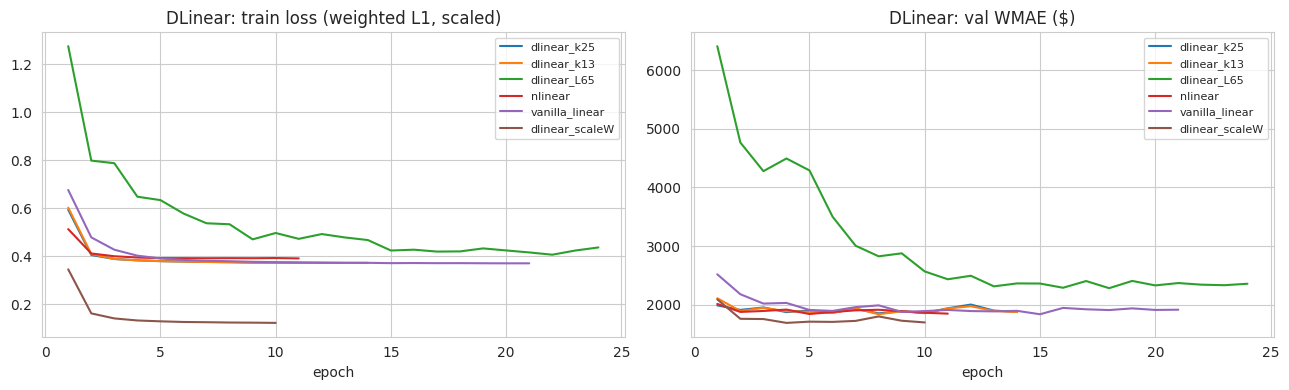

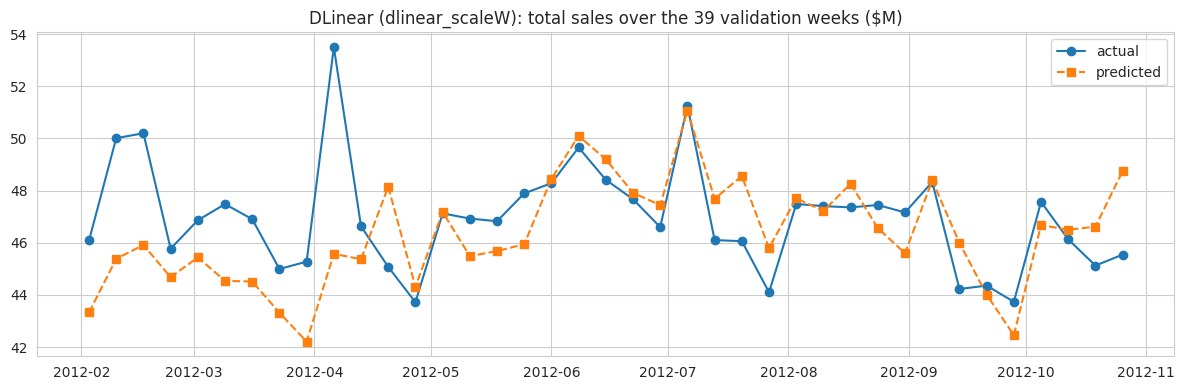

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for name, hist in HISTORIES.items():
    h = pd.DataFrame(hist)
    axes[0].plot(h.epoch, h.train_loss, label=name)
    if "val_wmae" in h:
        axes[1].plot(h.epoch, h.val_wmae, label=name)
axes[0].set_title(f"{ARCH}: train loss (weighted L1, scaled)")
axes[1].set_title(f"{ARCH}: val WMAE ($)")
for ax in axes:
    ax.set_xlabel("epoch"); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(f"pictures/{ARCH.lower()}_curves.png", dpi=120); plt.show()

_, mval = val_wmae_of(BEST_MODEL, BEST_CFG["L"])
fig, ax = plt.subplots(figsize=(12, 4))
a = mval.groupby("Date").Weekly_Sales.sum() / 1e6
p = mval.groupby("Date").pred.sum() / 1e6
ax.plot(a.index, a.values, "o-", label="actual")
ax.plot(p.index, p.values, "s--", label="predicted")
ax.set_title(f"{ARCH} ({BEST_CFG['name']}): total sales over the 39 validation weeks ($M)")
ax.legend()
plt.tight_layout(); plt.savefig(f"pictures/{ARCH.lower()}_val_total.png", dpi=120); plt.show()

### W&B sweep (bonus)


In [15]:
RUN_SWEEP = True     
SWEEP_COUNT = 8

if RUN_SWEEP:
    sweep_id = wandb.sweep(
        {"method": "bayes",
         "metric": {"name": "best_val_wmae", "goal": "minimize"},
         "parameters": SWEEP_SPACE},
        project=WANDB_PROJECT, entity=WANDB_ENTITY)

    def _sweep_train():
        run = wandb.init(group=f"{ARCH}_Sweep")
        cfg = cfg_from_sweep(dict(wandb.config))
        cfg["name"] = f"sweep_{run.id}"
        torch.manual_seed(SEED)
        model = build_model(cfg, HORIZON).to(DEVICE)
        train_model(model, cfg, run_name=f"{ARCH}_{cfg['name']}",
                    log_wandb=True, init_wandb=False)

    wandb.agent(sweep_id, function=_sweep_train, count=SWEEP_COUNT)

Create sweep with ID: 7mkqtgy3
Sweep URL: https://wandb.ai/rkvit23-free-university-of-tbilisi-/walmart-final/sweeps/7mkqtgy3


wandb: Agent Starting Run: 53y30ha3 with config:
wandb: 	L: 65
wandb: 	kernel: 7
wandb: 	lr: 0.0015358101326299032
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


🏃 View run DLinear_sweep_53y30ha3 at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/5/runs/ffe909607bc9430d819fe2cd19cdf069
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/5


epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
train_loss,█▆▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_wmae,█▆▄▄▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_epoch,38
best_val_wmae,2590.74687
epoch,40
n_parameters,5148
train_loss,0.42333
val_wmae,2611.82413


wandb: Agent Starting Run: vyyp9spb with config:
wandb: 	L: 65
wandb: 	kernel: 7
wandb: 	lr: 0.01344539227866985
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


...

  early stop @ epoch 22 (best 2,435.9 @ 16)
🏃 View run DLinear_sweep_ddgn98py at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/5/runs/c2da460435fd4b1a98c87321b6cfb219
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/5


epoch,▁▁▂▂▂▃▃▃▄▄▄▅▅▅▆▆▆▇▇▇██
train_loss,█▅▄▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_wmae,██▄▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_epoch,16
best_val_wmae,2435.90128
epoch,22
n_parameters,5148
train_loss,0.40592
val_wmae,2522.61875


wandb: Agent Starting Run: msd5xoje with config:
wandb: 	L: 65
wandb: 	kernel: 25
wandb: 	lr: 0.0017733476398942463
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


  early stop @ epoch 40 (best 2,301.4 @ 34)
🏃 View run DLinear_sweep_msd5xoje at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/5/runs/1df47705c83b4950b412680ff03a2663
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/5


epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
train_loss,█▅▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_wmae,█▅▄▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_epoch,34
best_val_wmae,2301.39251
epoch,40
n_parameters,5148
train_loss,0.41325
val_wmae,2324.2953


## Final pipeline + submission


In [16]:
REGISTER_AS_BEST = False

torch.manual_seed(SEED)
final_model = build_model(BEST_CFG, HORIZON).to(DEVICE)
_ = train_model(final_model, BEST_CFG, run_name=f"{ARCH}_Final_Refit",
                log_wandb=False, t_max=T, epochs=BEST_EPOCHS, eval_val=False)

fb_table, GLOBAL_MEAN = prep.make_fallback_table(train_raw)


wrapper = TorchForecastPipeline(
    build_fn=build_model, cfg=BEST_CFG,
    state_dict={k: v.cpu() for k, v in final_model.state_dict().items()},
    hist_tail=Ys[:, T - BEST_CFG["L"]:T], scale_vec=scale,
    series_index=list(series_idx), train_end=TRAIN_END, horizon=HORIZON,
    fallback=fb_table, global_mean=GLOBAL_MEAN)

test_pred = wrapper.predict(None, test_raw[["Store", "Dept", "Date"]])
assert len(test_pred) == len(test_raw) and np.isfinite(test_pred).all()

with mlflow.start_run(run_name=f"{ARCH}_Final_Pipeline"):
    mlflow.log_params({f"best_{k}": str(v) for k, v in BEST_CFG.items()})
    mlflow.log_metric("val_wmae", best_overall["wmae"])
    mlflow.log_metric("final_epochs", BEST_EPOCHS)
    for _p in [f"pictures/{ARCH.lower()}_curves.png",
               f"pictures/{ARCH.lower()}_val_total.png"]:
        if os.path.exists(_p):
            mlflow.log_artifact(_p)
    mlflow.pyfunc.log_model(
        "model", python_model=wrapper, code_paths=CODE_PATHS,
        registered_model_name="WalmartBestModel" if REGISTER_AS_BEST else None)
    run_id = mlflow.active_run().info.run_id
print("pipeline logged, run_id =", run_id)

sub = ev.make_submission(test_raw, test_pred, f"submission_{ARCH}.csv")
print("saved:", f"submission_{ARCH}.csv")

🏃 View run DLinear_Final_Refit at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/5/runs/4c9d15993d41474684a65d93fe6a55a2
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/5


2026/07/11 15:21:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/11 15:21:24 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.
2026/07/11 15:21:38 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


🏃 View run DLinear_Final_Pipeline at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/5/runs/807417d5d7ea4205861438b226c084a1
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/5
pipeline logged, run_id = 807417d5d7ea4205861438b226c084a1
saved: submission_DLinear.csv
